# Macchi-Wang Time Series

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

from sklearn.ensemble import RandomForestRegressor

from itertools import product

from preprocessing.pipeline import preprocess_all
from preprocessing.visualization import plot_corr_matrix, plot_ccf_with_target

from models import (
    fit_rw_with_drift,
    expanding_window_forecast_rw_with_drift,
    fit_arima_model,
    forecast_arima_model,
    expanding_window_forecast_arima,
    align_lagged_with_train_test,
)

## Preprocessing

### Data Cleaning


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

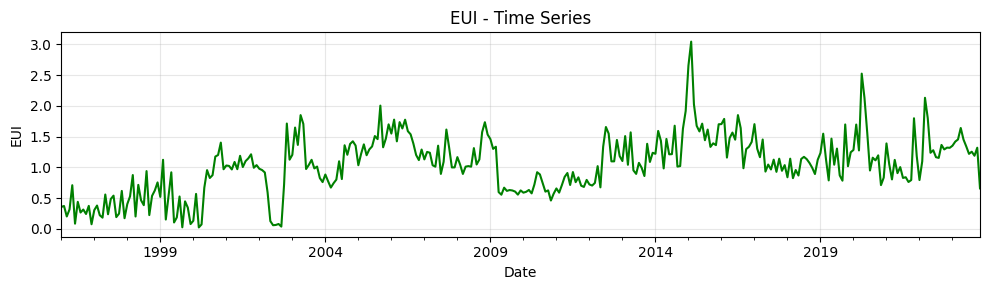

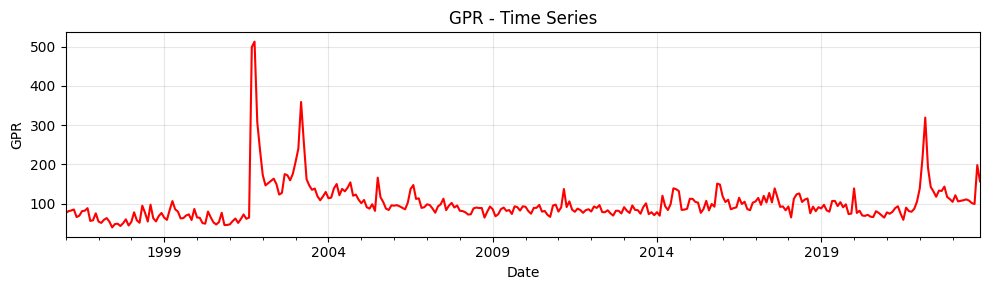

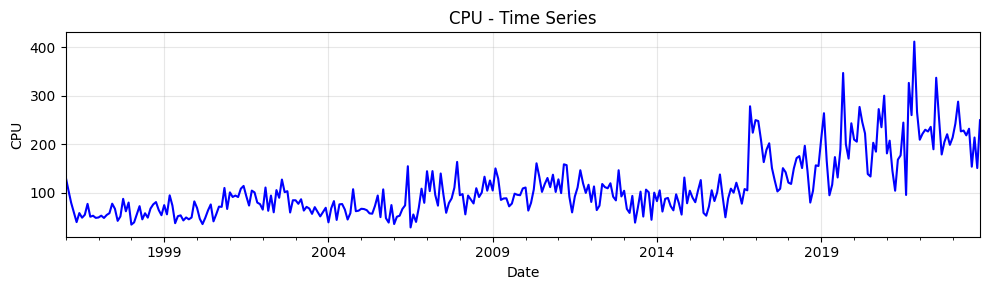

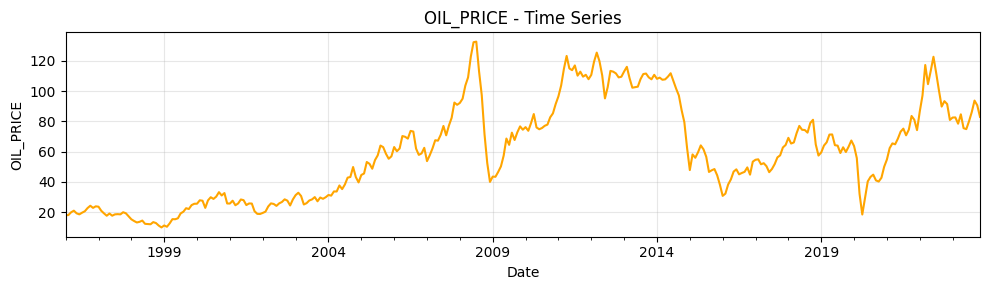

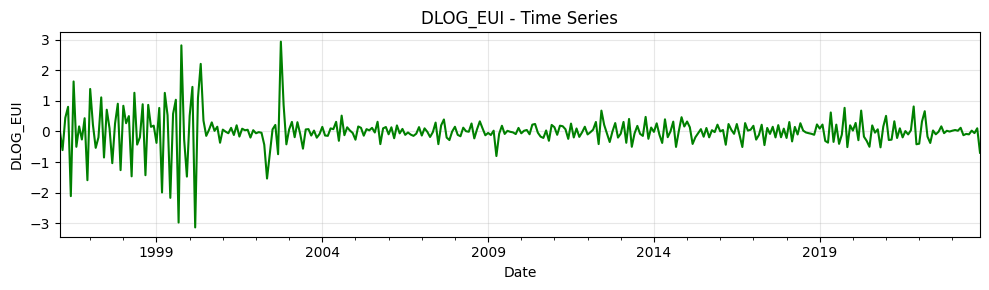

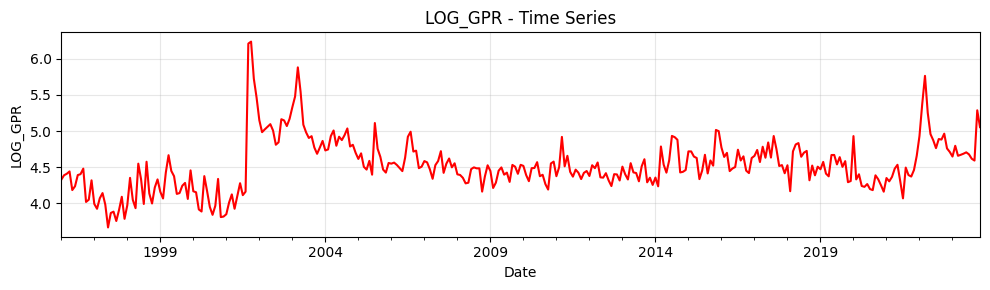

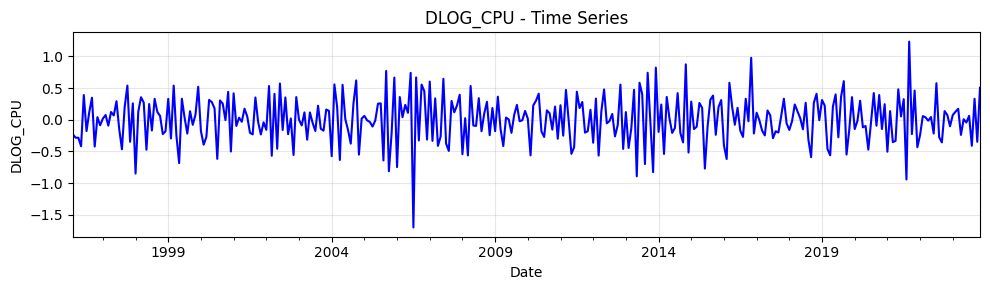

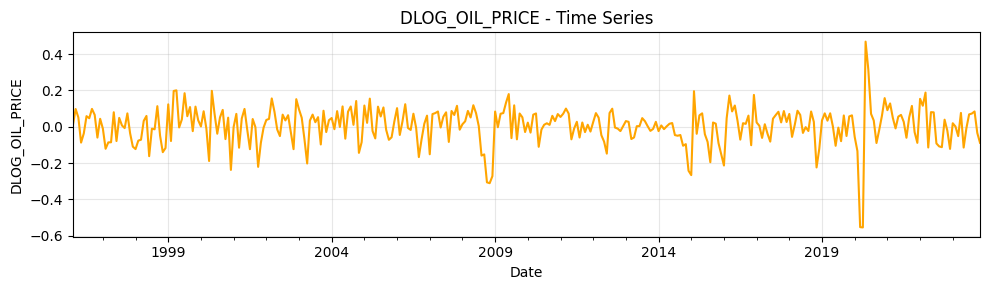

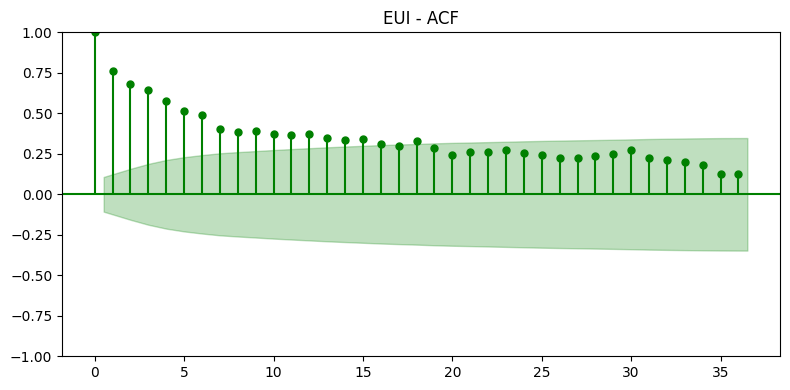

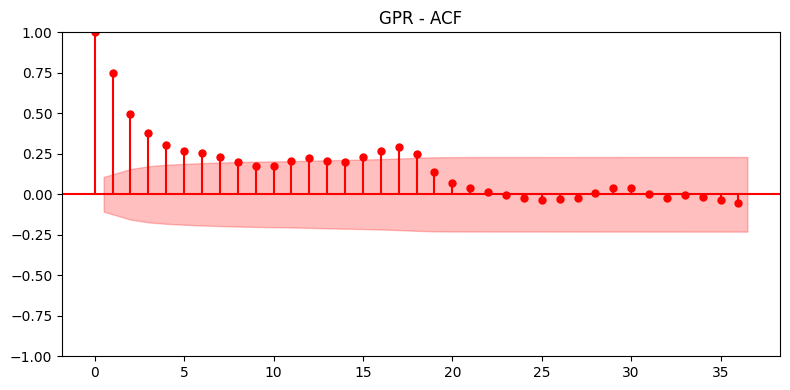

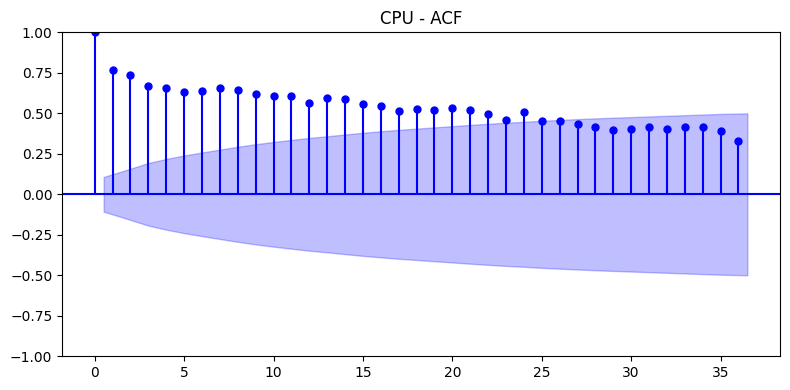

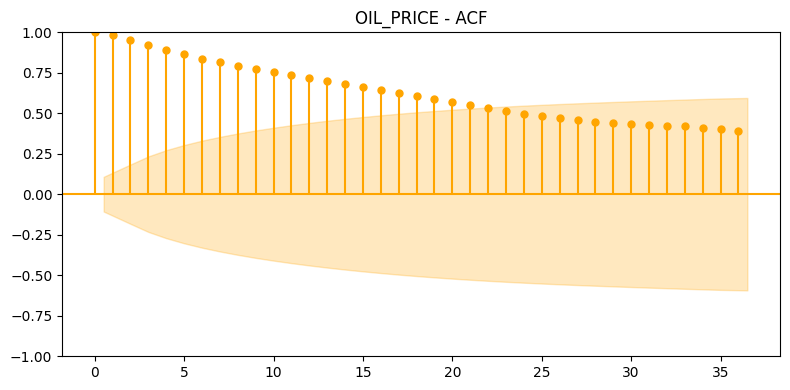

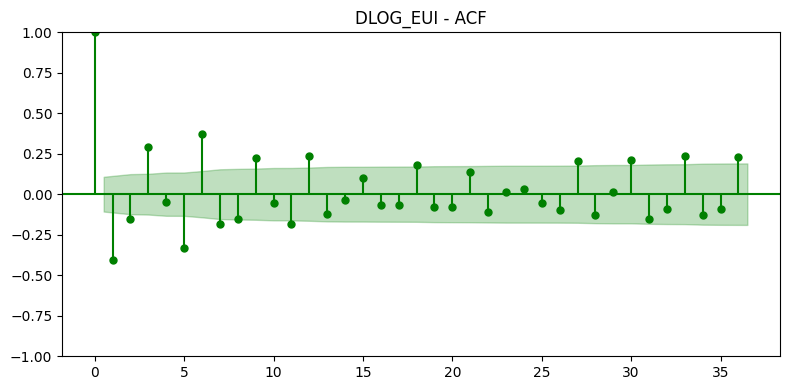

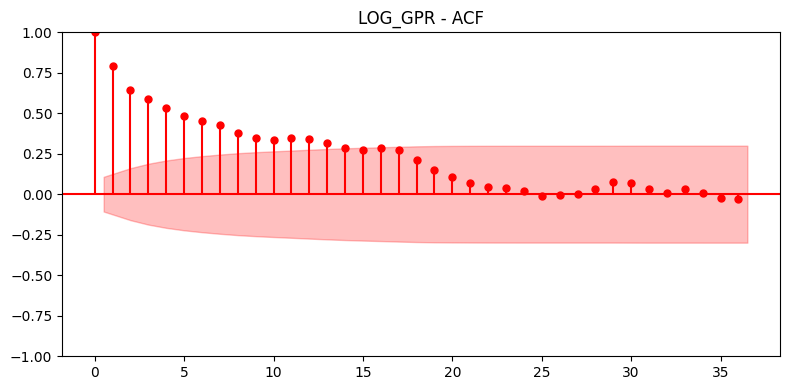

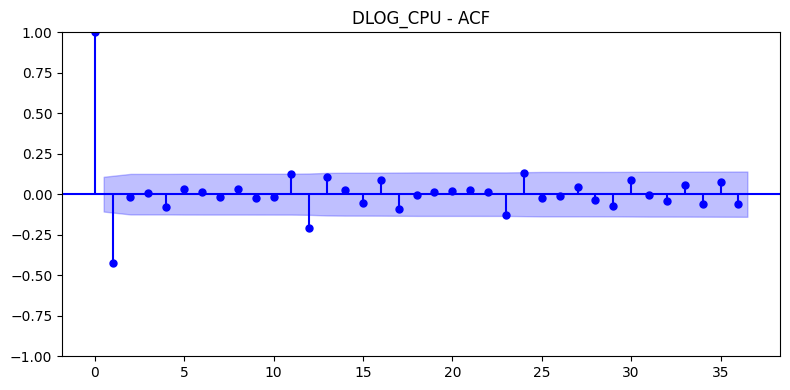

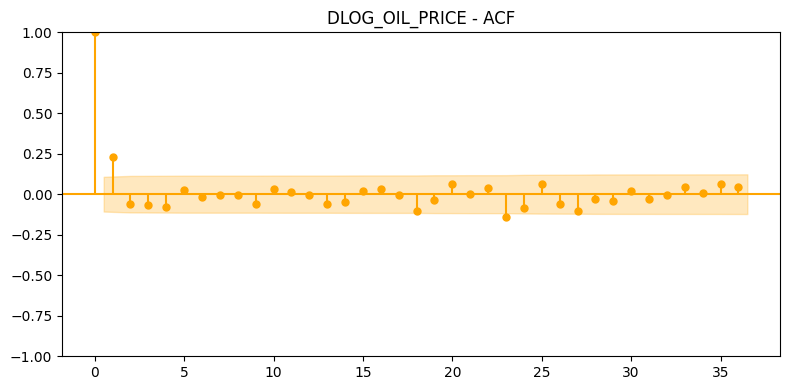

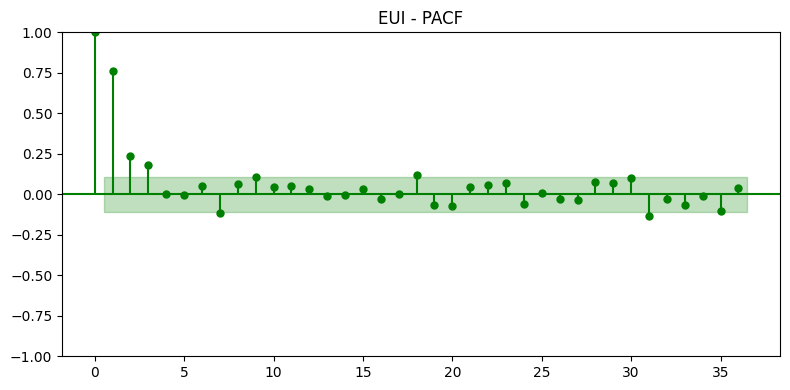

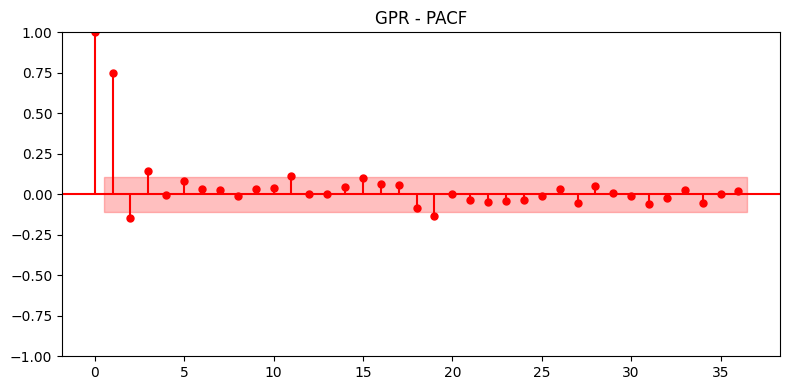

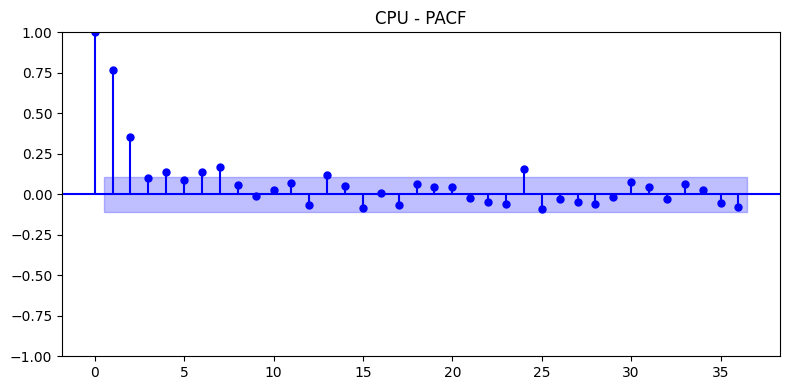

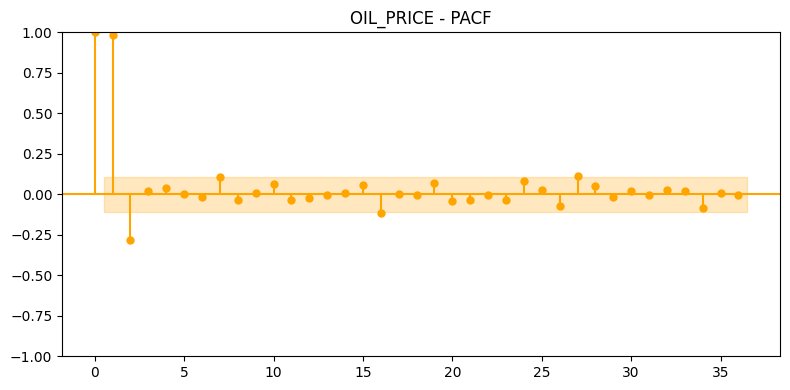

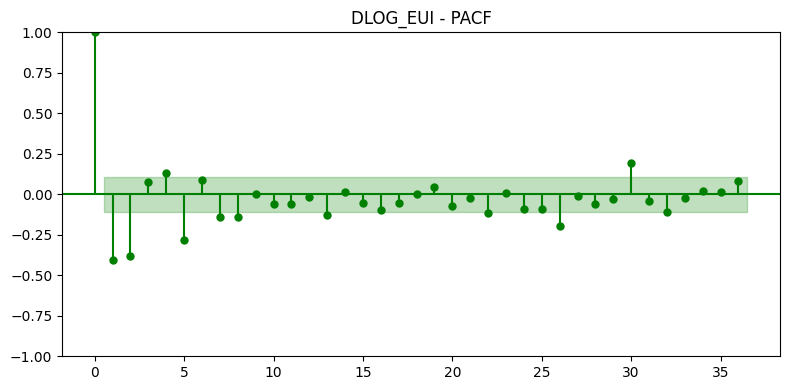

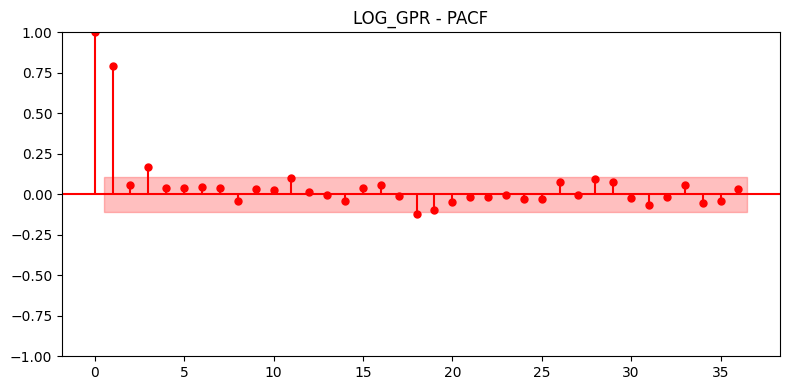

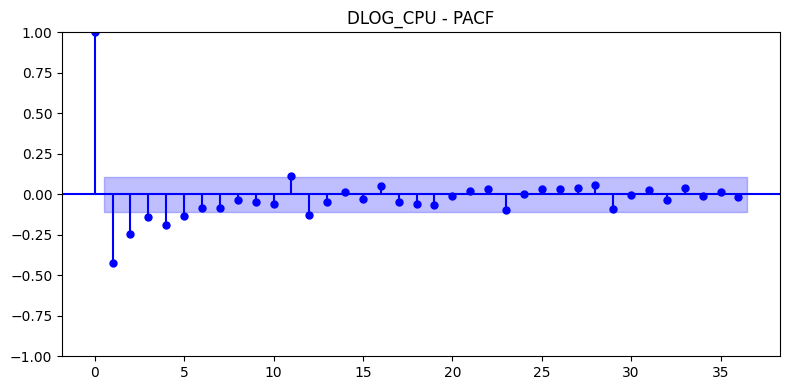

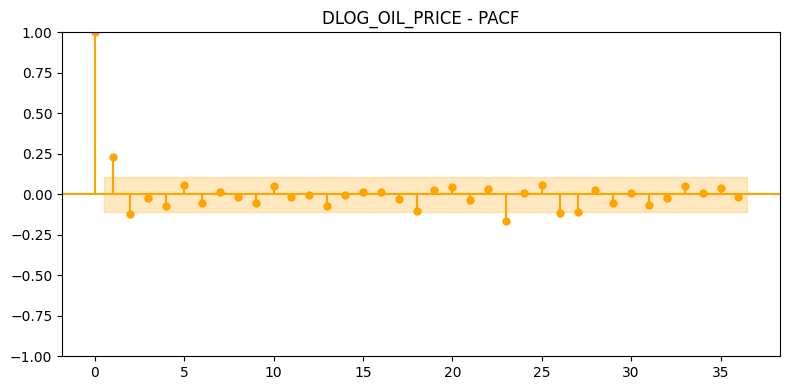

In [2]:
artifacts = preprocess_all(
    data_path="data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= {"variables": ("eui", "gpr", "cpu", "oil_price", "dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price",), "lags": 36, "time_series": True, "acf": True, "pacf": True, "pacf_method": "ywm",},
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

### Correlation

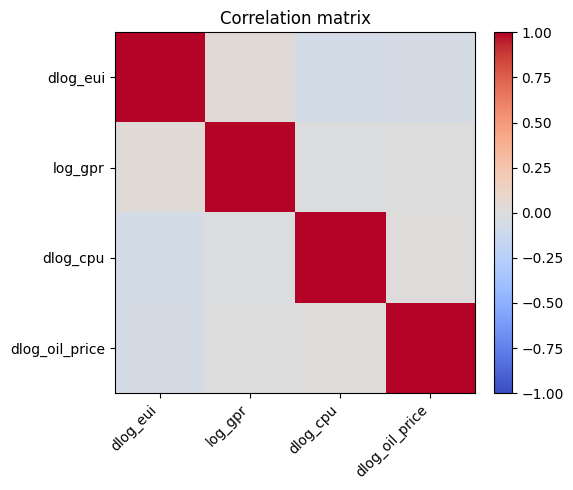

                dlog_eui   log_gpr  dlog_cpu  dlog_oil_price
dlog_eui        1.000000  0.027781 -0.063504       -0.059091
log_gpr         0.027781  1.000000 -0.009750       -0.005371
dlog_cpu       -0.063504 -0.009750  1.000000        0.004020
dlog_oil_price -0.059091 -0.005371  0.004020        1.000000


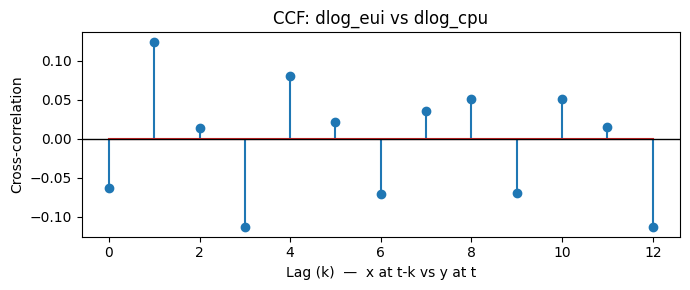

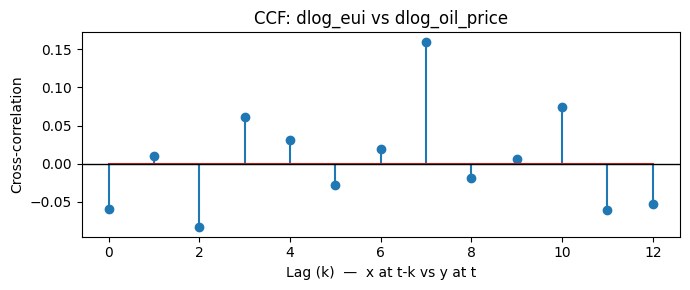

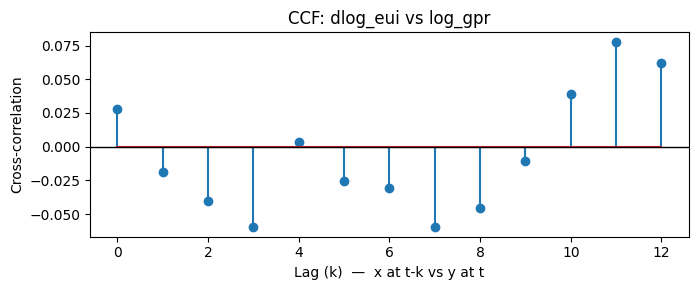

In [3]:
corr_vars = ["dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]
plot_corr_matrix(features_df, variables=corr_vars, date_col="date")

corr_matrix = features_df[corr_vars].corr()
print(corr_matrix)

plot_ccf_with_target(
    features_df,
    target="dlog_eui",
    predictors=["dlog_cpu", "dlog_oil_price", "log_gpr"],
    date_col="date",
    max_lag=12,
)


### TRAIN/TEST split

In [4]:
target_col = "log_eui"

### ADF Test

In [5]:
def adf_report(series: pd.Series, name: str, maxlag=None):
    s = series.dropna()
    res = adfuller(s, autolag="AIC" if maxlag is None else None, maxlag=maxlag)
    stat, pval, usedlag, nobs, crit, icbest = res
    print(f"\nADF test for {name}")
    print("---------------------------------")
    print(f"Test statistic: {stat:.4f}")
    print(f"p-value:        {pval:.4f}")
    print(f"Lags used:      {usedlag}")
    print(f"Observations:   {nobs}")
    print("Critical values:")
    for k, v in crit.items():
        print(f"  {k}: {v:.4f}")
    print(f"IC best:        {icbest:.4f}")


original_vars = ["eui", "gpr", "cpu", "oil_price"]
mod_vars = ["dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]

print("=== ADF on original level variables ===")
for v in original_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

print("\n=== ADF on dlog_ variables ===")
for v in mod_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

=== ADF on original level variables ===

ADF test for eui
---------------------------------
Test statistic: -2.7765
p-value:        0.0617
Lags used:      8
Observations:   259
Critical values:
  1%: -3.4559
  5%: -2.8728
  10%: -2.5728
IC best:        70.3549

ADF test for gpr
---------------------------------
Test statistic: -5.2192
p-value:        0.0000
Lags used:      2
Observations:   265
Critical values:
  1%: -3.4553
  5%: -2.8725
  10%: -2.5726
IC best:        2495.5884

ADF test for cpu
---------------------------------
Test statistic: -2.9250
p-value:        0.0425
Lags used:      4
Observations:   263
Critical values:
  1%: -3.4555
  5%: -2.8726
  10%: -2.5727
IC best:        2392.0513

ADF test for oil_price
---------------------------------
Test statistic: -1.9751
p-value:        0.2976
Lags used:      1
Observations:   266
Critical values:
  1%: -3.4552
  5%: -2.8725
  10%: -2.5726
IC best:        1513.6239

=== ADF on dlog_ variables ===

ADF test for dlog_eui
---------

## Random Walk with Drift

In [6]:
# ---------------------------------------------------
# 1. Random Walk with Drift (on levels)
#    with 1-step ahead expanding-window forecasts
# ---------------------------------------------------
y_train_log = train_df[target_col]
y_test_log  = test_df[target_col]

# Fit once on the training sample (for in-sample residuals, etc.)
rw_fit = fit_rw_with_drift(y_train_log)

# Out-of-sample 1-step-ahead forecasts via expanding window
rw_fcast = expanding_window_forecast_rw_with_drift(
    y_train=y_train_log,
    y_test=y_test_log,
)

### Residuals

In [7]:
mu_rw = rw_fit["mu"]
y_train = y_train_log

# fitted(t) = y_{t-1} + mu
rw_fitted_in = y_train.shift(1) + mu_rw

rw_resid_in = (y_train - rw_fitted_in).dropna()
rw_resid_in.name = "rw_resid_in"

print("\nRW — in-sample residuals (head):")
print(rw_resid_in.head())


RW — in-sample residuals (head):
date
1996-02-01    0.037172
1996-03-01   -0.612036
1996-04-01    0.444506
1996-05-01    0.801428
1996-06-01   -2.115001
Name: rw_resid_in, dtype: float64


### Forecast

In [8]:
# Forecast errors (out-of-sample) per RW
rw_resid_oos = (y_test_log - rw_fcast).dropna()
rw_resid_oos.name = "rw_resid_oos"

print("\nRW — out-of-sample forecast errors:")
print(rw_resid_oos.head())


RW — out-of-sample forecast errors:
date
2018-05-01   -0.101613
2018-06-01    0.266094
2018-07-01    0.025731
2018-08-01   -0.036499
2018-09-01   -0.060217
Name: rw_resid_oos, dtype: float64


## ARIMA

### Best ARIMA

In [9]:
y_train_arima = train_df[target_col]
y_test_arima = test_df[target_col]

# Grid search for ARIMA(p,d,q)
orders_to_try = [
    (p, d, q)
    for p in range(0, 9)  # p = 0..5
    for d in range(0, 2)
    for q in range(0, 9)  # q = 0..5
]

seasonal_order = (0, 0, 0, 0)

arima_models = {}
arima_forecasts = {}
arima_errors = {}
arima_results = []

for order in orders_to_try:
    print(f"\n=== Fitting ARIMA{order} on {target_col} ===")
    try:
        res = fit_arima_model(
            y=y_train_arima,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
    except Exception as e:
        print(f"  FAILED for order {order}: {e}")
        continue

    arima_models[order] = res

    # Forecast on test set
    fcast = forecast_arima_model(
        res=res,
        steps=len(y_test_arima),
        index=y_test_arima.index,
    )
    arima_forecasts[order] = fcast

    # Forecast errors out-of-sample
    errors = (y_test_arima - fcast).dropna()
    arima_errors[order] = errors

    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))

    # Residuals in-sample
    resid_in = res.resid.dropna()

    # Ljung–Box on in-sample residuals
    lb = acorr_ljungbox(resid_in, lags=[12, 24, 36], return_df=True)

    arima_results.append({
        "order": order,
        "aic": res.aic,
        "bic": res.bic,
        "rmse": rmse,
        "lb_pvalue_12": lb.loc[12, "lb_pvalue"],
        "lb_pvalue_24": lb.loc[24, "lb_pvalue"],
        "lb_pvalue_36": lb.loc[36, "lb_pvalue"],
    })

# Table summary
arima_df = pd.DataFrame(arima_results).sort_values(by="aic")
print("\n=== ARIMA model comparison (sorted by AIC) ===")
print(arima_df)

# Choose the best ARIMA (with lower RMSE)
best_order = tuple(arima_df.iloc[0]["order"])
print(f"\nBest ARIMA order: {best_order}")

arima_best_model = arima_models[best_order]


=== Fitting ARIMA(0, 0, 0) on log_eui ===

=== Fitting ARIMA(0, 0, 1) on log_eui ===

=== Fitting ARIMA(0, 0, 2) on log_eui ===

=== Fitting ARIMA(0, 0, 3) on log_eui ===

=== Fitting ARIMA(0, 0, 4) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(0, 0, 5) on log_eui ===

=== Fitting ARIMA(0, 0, 6) on log_eui ===

=== Fitting ARIMA(0, 0, 7) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(0, 0, 8) on log_eui ===

=== Fitting ARIMA(0, 1, 0) on log_eui ===

=== Fitting ARIMA(0, 1, 1) on log_eui ===

=== Fitting ARIMA(0, 1, 2) on log_eui ===


...

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


=== Fitting ARIMA(8, 1, 7) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


=== Fitting ARIMA(8, 1, 8) on log_eui ===

=== ARIMA model comparison (sorted by AIC) ===
         order         aic         bic      rmse   lb_pvalue_12  \
149  (8, 0, 5)  337.965872  391.376097  0.277529   1.389087e-01   
98   (5, 0, 8)  340.318299  393.670720  0.273132   9.875601e-01   
116  (6, 0, 8)  341.192712  398.101961  0.269747   7.609630e-01   
130  (7, 0, 4)  341.204643  387.543408  0.273032   5.852980e-01   
96   (5, 0, 6)  341.297852  387.636617  0.276451   9.037865e-01   
..         ...         ...         ...       ...            ...   
18   (1, 0, 0)  458.633093  469.394839  0.447358   2.666171e-26   
9    (0, 1, 0)  500.133621  503.717117  0.339799   5.355005e-38   
2    (0, 0, 2)  506.910760  521.229679  0.450654   4.477661e-42   
1    (0, 0, 1)  525.673827  536.424316  0.454171   2.435097e-54   
0    (0, 0, 0)  625.457244  632.631742  0.455905  5.367313e-136   

      lb_pvalue_24   lb_pvalue_36  
149   1.611820e-01   7.289584e-03  
98    9.405017e-01   7.345042e-0

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Residuals

In [10]:
arima_best_resid_in = arima_best_model.resid.dropna()

arima_best_resid_in.name = "arima_best_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_best_resid_in.head())


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -1.152148
1996-02-01   -0.227962
1996-03-01   -1.319280
1996-04-01    0.346470
1996-05-01    0.777962
Name: arima_best_resid_in, dtype: float64


#### Forecast

In [11]:
# Expanding-window 1-step-ahead forecasts on the test set
arima_best_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=best_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# Out-of-sample forecast errors (1-step-ahead, expanding window)
arima_best_errors_oos = (y_test_arima - arima_best_forecast).dropna()
arima_best_errors_oos.name = "arima_best_errors_oos"

rmse = float(np.sqrt(np.mean(arima_best_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nBest ARIMA (expanding window) — out-of-sample forecast errors (head):")
print(arima_best_errors_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  


RMSE (1-step expanding window): 0.28523686802921366

Best ARIMA (expanding window) — out-of-sample forecast errors (head):
date
2018-05-01   -0.097034
2018-06-01    0.166236
2018-07-01    0.114988
2018-08-01   -0.120638
2018-09-01   -0.012535
Name: arima_best_errors_oos, dtype: float64


### ARIMA (2,1,0)

In [12]:
# ===========================================
# Run ARIMA for ONE SET of PARAMETERS (p,d,q)
# ===========================================

# Choose the ARIMA order manually
order = (2, 1, 0)      # <-- put your numbers here, e.g. (2,1,0)
seasonal_order = (0, 0, 0, 0)

print(f"\n=== Fitting ARIMA{order} on {target_col} ===")

# ---- Fit model ----
res = fit_arima_model(
    y=y_train_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# ---- Forecast on test set ----
fcast = forecast_arima_model(
    res=res,
    steps=len(y_test_arima),
    index=y_test_arima.index,
)

# ---- Forecast errors ----
errors = (y_test_arima - fcast).dropna()
mse = float(np.mean(errors ** 2))
rmse = float(np.sqrt(mse))

# ---- Residual diagnostics ----
resid_in = res.resid.dropna()
lb = acorr_ljungbox(resid_in, lags=[12, 24], return_df=True)

print("\n=== RESULTS ===")
print(f"AIC:  {res.aic}")
print(f"BIC:  {res.bic}")
print(f"RMSE: {rmse}")
print("\nLjung–Box p-values:")
print(lb)

# Optional: store outputs
arima_210_model = res
arima_210_forecast = fcast


=== Fitting ARIMA(2, 1, 0) on log_eui ===

=== RESULTS ===
AIC:  409.8266987564805
BIC:  420.56588823443917
RMSE: 0.3457255967785004

Ljung–Box p-values:
      lb_stat  lb_pvalue
12  46.901049   0.000005
24  61.471967   0.000039


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [13]:
arima_210_resid_in = arima_210_model.resid.dropna()

arima_210_resid_in.name = "arima_210_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_210_resid_in.head())


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -1.026573
1996-02-01   -0.252815
1996-03-01   -0.758698
1996-04-01    0.115863
1996-05-01    0.827278
Name: arima_210_resid_in, dtype: float64


#### Forecasts

In [14]:
# ===========================================
# 1-step-ahead EXPANDING-WINDOW forecasts
# ===========================================

print("\n=== 1-step-ahead expanding-window forecasts on TEST sample ===")

arima_210_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# ---- OOS errors ----
arima_210_errors_oos = (y_test_arima - arima_210_forecast).dropna()
arima_210_errors_oos.name = "arima_210_errors_oos"

rmse = float(np.sqrt(np.mean(arima_210_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nHEAD of 1-step expanding-window forecast errors:")
print(arima_210_errors_oos.head())



=== 1-step-ahead expanding-window forecasts on TEST sample ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


RMSE (1-step expanding window): 0.27845839211101064

HEAD of 1-step expanding-window forecast errors:
date
2018-05-01   -0.137689
2018-06-01    0.270617
2018-07-01    0.146566
2018-08-01    0.088587
2018-09-01   -0.062788
Name: arima_210_errors_oos, dtype: float64


## VAR

In [32]:
var_endog_cols = ["dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 2. Lag order selection (AIC) on TRAIN sample only
# -----------------------------
max_lags_var = 36  # adjustable
lag_order_res = VAR(endog_train_var).select_order(maxlags=max_lags_var)
print(lag_order_res.summary())
best_lag_var = lag_order_res.selected_orders["aic"]
print(f"\nBest VAR lag (AIC): {best_lag_var}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.908      -9.848   4.979e-05      -9.884
1       -11.16     -10.86*   1.422e-05      -11.04
2       -11.32      -10.79   1.209e-05     -11.11*
3       -11.33      -10.55   1.202e-05      -11.02
4       -11.35      -10.34   1.177e-05      -10.94
5       -11.39      -10.14   1.130e-05      -10.89
6       -11.37      -9.880   1.158e-05      -10.77
7      -11.41*      -9.684  1.111e-05*      -10.72
8       -11.33      -9.363   1.210e-05      -10.54
9       -11.29      -9.085   1.263e-05      -10.40
10      -11.24      -8.791   1.340e-05      -10.25
11      -11.30      -8.618   1.262e-05      -10.22
12      -11.24      -8.315   1.354e-05      -10.06
13      -11.28      -8.117   1.310e-05      -10.00
14      -11.22      -7.818   1.403e-05      -9.845
15      -11.16      -7.528   1.492e-05      -9.697
16      -11.17      -7.293   1.

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Residuals

In [33]:
# -----------------------------
# 3. Fit VAR on entire TRAIN sample (no dummies)
# -----------------------------
var_model_train = VAR(endog_train_var)
var_res_train = var_model_train.fit(best_lag_var)
print(var_res_train.summary())

# In-sample fitted dlog_eui (already in log difference)
var_fitted_dlog = var_res_train.fittedvalues["dlog_eui"]

# In-sample residuals in LOG DIFFERENCE space
actual_dlog_train = endog_train_var.loc[var_fitted_dlog.index, "dlog_eui"]
var_resid_in = (actual_dlog_train - var_fitted_dlog).dropna()
var_resid_in.name = "var_resid_in"
print("\nVAR — in-sample residuals (log difference, head):")
print(var_resid_in.head())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 24, Nov, 2025
Time:                     17:05:59
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -9.75603
Nobs:                     260.000    HQIC:                  -10.7060
Log likelihood:           115.107    FPE:                1.18769e-05
AIC:                     -11.3446    Det(Omega_mle):     7.78049e-06
--------------------------------------------------------------------
Results for equation dlog_eui
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.548171         0.412658            1.328           0.184
L1.dlog_eui              -0.420886         0.062995           -6.681           0.000
L1.log_gpr                0.130971       

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Forecast

In [34]:
# -----------------------------
# 4. Expanding-window 1-step-ahead forecasts (no exog)
# -----------------------------
test_index = test_df.index
n_train = len(train_df)
var_dlog_eui_fcast = []

for i, current_date in enumerate(test_index):
    # Up to t-1 in full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR for this window
    var_model_i = VAR(endog_train_i)
    var_res_i = var_model_i.fit(best_lag_var)

    # last best_lag_var observations
    y_history = endog_train_i.values[-best_lag_var:]

    # 1-step-ahead forecast (NO exog)
    fcast_i = var_res_i.forecast(y=y_history, steps=1)

    # extract dlog_eui forecast
    dlog_eui_idx = endog_train_i.columns.get_loc("dlog_eui")
    dlog_eui_hat = fcast_i[0, dlog_eui_idx]
    var_dlog_eui_fcast.append(dlog_eui_hat)

# Series of VAR forecasts (dlog_eui)
var_dlog_eui_fcast_series = pd.Series(
    var_dlog_eui_fcast,
    index=test_index,
    name="var_dlog_eui_fcast"
)
print("\nVAR — 1-step-ahead forecasts (dlog_eui, head):")
print(var_dlog_eui_fcast_series.head())

# -----------------------------
# 5. Convert VAR dlog forecasts to LOG EUI (test)
# -----------------------------
# Get log(EUI) from the full data
full_log_eui = pd.concat([train_df["log_eui"], test_df["log_eui"]])
prev_log_eui_test = full_log_eui.shift(1).loc[test_index]

# Forecasted log(EUI) = previous log(EUI) + forecasted dlog_eui
var_log_eui_forecast = prev_log_eui_test + var_dlog_eui_fcast_series
var_log_eui_forecast.name = "var_log_eui_forecast"
print("\nVAR — 1-step-ahead forecasts for log(EUI), head:")
print(var_log_eui_forecast.head())

# -----------------------------
# 6. Out-of-sample forecast errors (in log space)
# -----------------------------
# Actual log(EUI) in test set
actual_log_eui_test = test_df.loc[test_index, "log_eui"]

# Forecast errors in log space
var_resid_oos = (actual_log_eui_test - var_log_eui_forecast).dropna()
var_resid_oos.name = "var_resid_oos"
print("\nVAR — out-of-sample forecast errors (log space, head):")
print(var_resid_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


VAR — 1-step-ahead forecasts (dlog_eui, head):
date
2018-05-01    0.261038
2018-06-01   -0.073042
2018-07-01   -0.194080
2018-08-01    0.186944
2018-09-01    0.059415
Name: var_dlog_eui_fcast, dtype: float64

VAR — 1-step-ahead forecasts for log(EUI), head:
date
2018-05-01    0.218506
2018-06-01   -0.213502
2018-07-01   -0.065139
2018-08-01    0.345910
2018-09-01    0.186273
Name: var_log_eui_forecast, dtype: float64

VAR — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.358966
2018-06-01    0.342442
2018-07-01    0.224106
2018-08-01   -0.219052
2018-09-01   -0.115375
Name: var_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b

## Random Forest

In [18]:
# ---------------------------------------------------
# 1. Create RF lagged-feature dataset
# ---------------------------------------------------

rf_feature_cols = [
    "log_gpr", "log_cpu", "log_oil_price",
    "COVID_WINDOW_2020_03_11_2023_05_05",
    "RU_UA_WAR_PULSE_2022_02_24",
    "FUKUSHIMA_PULSE_2011_03_11",
    "GFC_WINDOW_2007_12_01_2009_06_30",
    "PARIS_COP21_PULSE_2015_12_12",
    "SEP11_PULSE_2001_09_11",
]

X_train_rf, y_train_rf, X_test_rf, y_test_rf = align_lagged_with_train_test(
    features_df=features_df,
    train_df=train_df,
    test_df=test_df,
    target_col=target_col,
    feature_cols=rf_feature_cols,
    max_lag=48,
    date_col="date",
)

print("Shapes:")
print("X_train_rf:", X_train_rf.shape)
print("y_train_rf:", y_train_rf.shape)
print("X_test_rf:", X_test_rf.shape)
print("y_test_rf:", y_test_rf.shape)

# ---------------------------------------------------
# 2. Define RF param_grid as dict of lists
# ---------------------------------------------------

param_grid = {"n_estimators": [200, 300, 500], "max_depth": [3, 4, 5], "min_samples_leaf": [1, 2, 4],}

# From the grid above the best params are:

# === RF Time-series CV results (sorted by MSFE) ===
#     n_estimators  max_depth  min_samples_leaf   cv_msfe
# 24           500          5                 1  0.053973
# 15           300          5                 1  0.054652
# 21           500          4                 1  0.054652
# 25           500          5                 2  0.054810
# 3            200          4                 1  0.055036

# Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}


#For computational efficiency, we simply use the best params found above.

param_grid = {"n_estimators": [500], "max_depth": [5], "min_samples_leaf": [1],}

# ---------------------------------------------------
# 3. Time-series CV scoring for one param combination
# ---------------------------------------------------

def ts_cv_score_rf(
        X, y,
        params,
        initial_train_size,
        h=1,
        step=1,
        random_state=6,
):
    """
    Expanding-window CV for RF.
    Returns mean MSFE (mean squared forecast error).
    """
    n = len(y)
    msfes = []

    train_start = 0
    train_end = initial_train_size

    while True:
        test_start = train_end
        test_end = test_start + h

        if test_end > n:
            break

        X_train_cv = X.iloc[train_start:train_end]
        y_train_cv = y.iloc[train_start:train_end]
        X_test_cv = X.iloc[test_start:test_end]
        y_test_cv = y.iloc[test_start:test_end]

        rf = RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
            **params,
        )
        rf.fit(X_train_cv, y_train_cv)
        y_pred_cv = rf.predict(X_test_cv)

        msfe = np.mean((y_test_cv.values - y_pred_cv) ** 2)
        msfes.append(msfe)

        train_end += step  # expand window

    return np.mean(msfes) if msfes else np.inf


# ---------------------------------------------------
# 4. Loop over all combinations of the param_grid
# ---------------------------------------------------

keys = list(param_grid.keys())
values_product = list(product(*param_grid.values()))

cv_results = []
initial_train_size = int(len(y_train_rf) * 0.5)

print("\nStarting RF Grid Search...\n")

for vals in values_product:
    params = dict(zip(keys, vals))
    print("Testing:", params)

    msfe_cv = ts_cv_score_rf(
        X=X_train_rf,
        y=y_train_rf,
        params=params,
        initial_train_size=initial_train_size,
        h=1,
        step=1,
        random_state=6,
    )

    cv_results.append({**params, "cv_msfe": msfe_cv})

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_msfe")
print("\n=== RF Time-series CV results (sorted by MSFE) ===")
print(cv_results_df.head())

# ---------------------------------------------------
# 5. Select best parameters
# ---------------------------------------------------

best = cv_results_df.iloc[0]
best_params = {
    "n_estimators": int(best["n_estimators"]),
    "max_depth": int(best["max_depth"]),
    "min_samples_leaf": int(best["min_samples_leaf"]),
}

print("\nBest RF params:", best_params)

# ---------------------------------------------------
# 6. Fit final RF on full training set & forecast test
# ---------------------------------------------------

rf_best = RandomForestRegressor(
    n_jobs=-1,
    random_state=6,
    **best_params,
)

rf_best.fit(X_train_rf, y_train_rf)

rf_fcast = rf_best.predict(X_test_rf)
rf_fcast_series = pd.Series(rf_fcast, index=X_test_rf.index, name="rf_forecast")

print("\nRandom Forest final forecast (head):")
print(rf_fcast_series.head())

# ---------------------------------------------------
# 7. Basic metric: RF feature importances
# ---------------------------------------------------

# Extract feature importances
importances = rf_best.feature_importances_

# Build a dataframe
feat_imp_df = (
    pd.DataFrame({
        "feature": X_train_rf.columns,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Random Forest Feature Importances (MDI) ===")
print(feat_imp_df.head(20))  # show top 20


Shapes:
X_train_rf: (220, 480)
y_train_rf: (220,)
X_test_rf: (67, 480)
y_test_rf: (67,)

Starting RF Grid Search...

Testing: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

=== RF Time-series CV results (sorted by MSFE) ===
   n_estimators  max_depth  min_samples_leaf   cv_msfe
0           500          5                 1  0.056913

Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

Random Forest final forecast (head):
date
2018-05-01   -0.099504
2018-06-01   -0.088976
2018-07-01   -0.019304
2018-08-01    0.131340
2018-09-01    0.092905
Name: rf_forecast, dtype: float64

=== Random Forest Feature Importances (MDI) ===
                feature  importance
0    log_oil_price_lag7    0.344245
1    log_oil_price_lag6    0.138452
2    log_oil_price_lag8    0.129453
3          log_eui_lag1    0.123898
4          log_eui_lag2    0.061253
5   log_oil_price_lag43    0.011329
6    log_oil_price_lag9    0.010657
7    log_oil_price_lag5    0.006889
8       

### Residuals

In [19]:
# Fitted values sul training per RF
rf_fitted_in = rf_best.predict(X_train_rf)
rf_fitted_in = pd.Series(rf_fitted_in, index=X_train_rf.index, name="rf_fitted_in")

# Residui in-sample RF
rf_resid_in = (y_train_rf - rf_fitted_in).dropna()
rf_resid_in.name = "rf_resid_in"

print("\nRF — in-sample residuals:")
print(rf_resid_in.head())


RF — in-sample residuals:
date
2000-01-01    0.174274
2000-02-01    0.743860
2000-03-01   -0.694253
2000-04-01   -0.646455
2000-05-01    0.445042
Name: rf_resid_in, dtype: float64


### Forecast

In [20]:
# Forecast errors (out-of-sample) RF
rf_resid_oos = (y_test_rf - rf_fcast_series).dropna()
rf_resid_oos.name = "rf_resid_oos"

print("\nRF — out-of-sample forecast errors:")
print(rf_resid_oos.head())


RF — out-of-sample forecast errors:
date
2018-05-01   -0.040956
2018-06-01    0.217916
2018-07-01    0.178271
2018-08-01   -0.004481
2018-09-01   -0.022007
Name: rf_resid_oos, dtype: float64


## Final Results

### Confront the residuals


Random Walk with Drift (in-sample, level)
------------------------------
Mean:   0.000000
Std:    0.617172
Min:    -3.137274
Max:    2.930597

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
12  224.326707  3.004466e-41
24  260.351341  1.452476e-41
30  300.208381  2.409172e-46
36  353.941194  7.070875e-54
48  419.843145  7.536207e-61


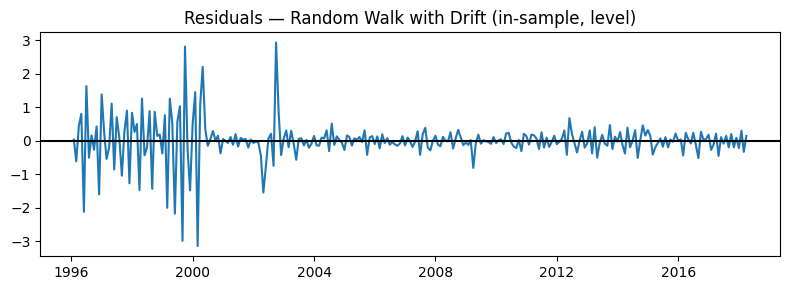

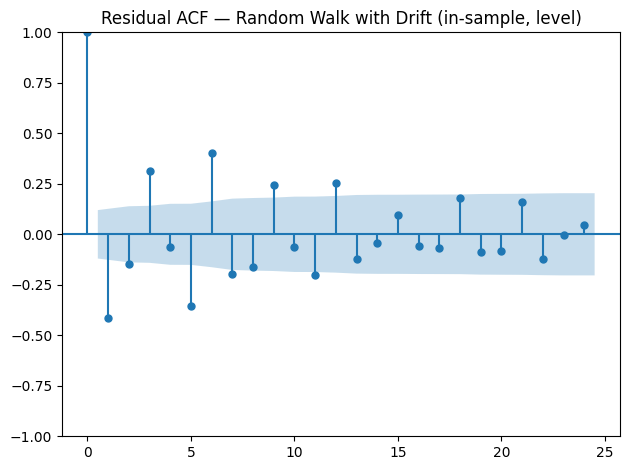

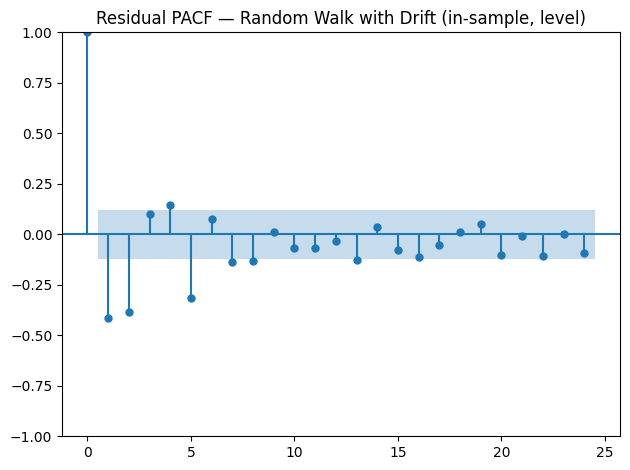


Best ARIMA(8, 0, 5) (in-sample, level)
------------------------------
Mean:   0.001547
Std:    0.522560
Min:    -2.160027
Max:    2.591637

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
12   46.901049  4.849207e-06
24   61.471967  3.947085e-05
30   92.629159  2.608867e-08
36  101.793250  3.381905e-08
48  117.339059  9.774367e-08


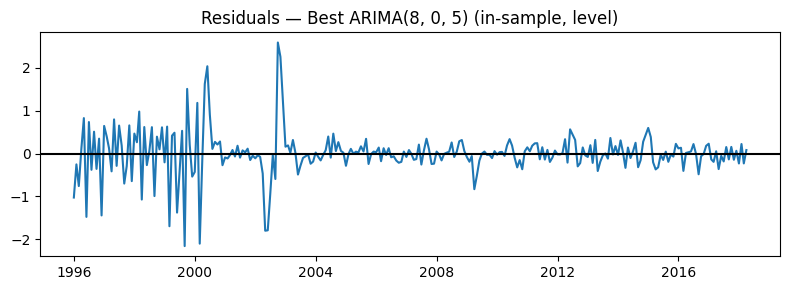

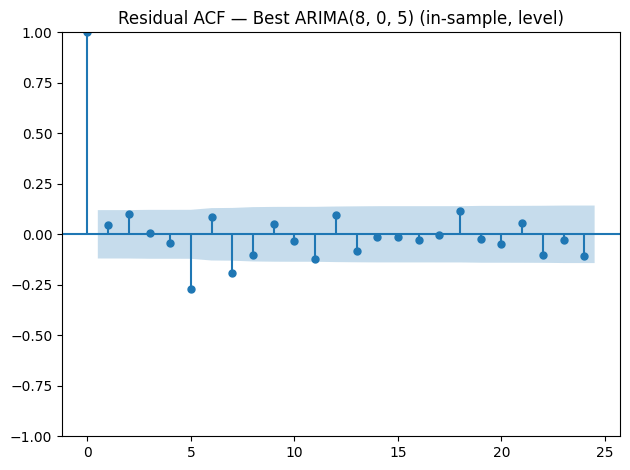

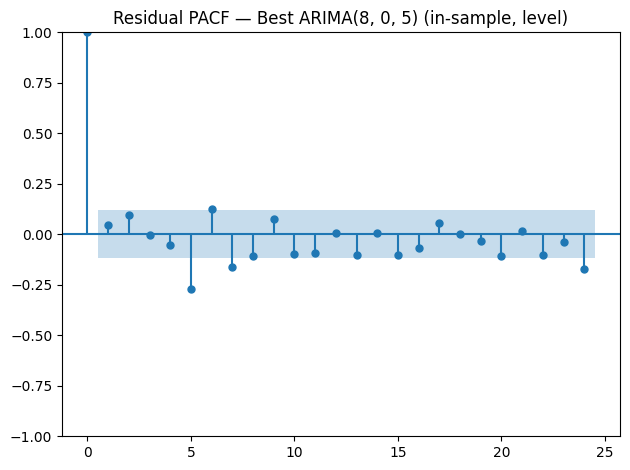


ARIMA(2,1,0) (in-sample, level)
------------------------------
Mean:   0.001547
Std:    0.522560
Min:    -2.160027
Max:    2.591637

Ljung–Box test (H0: no autocorrelation)
       lb_stat     lb_pvalue
12   46.901049  4.849207e-06
24   61.471967  3.947085e-05
30   92.629159  2.608867e-08
36  101.793250  3.381905e-08
48  117.339059  9.774367e-08


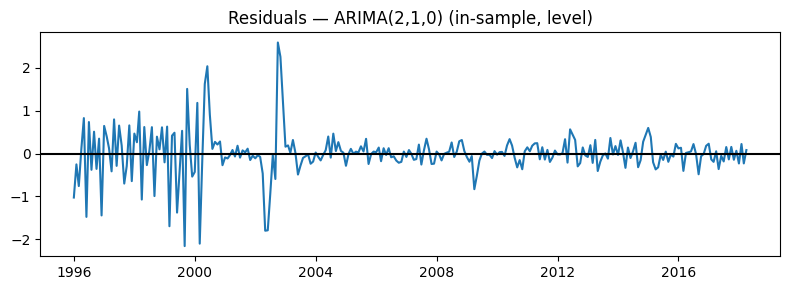

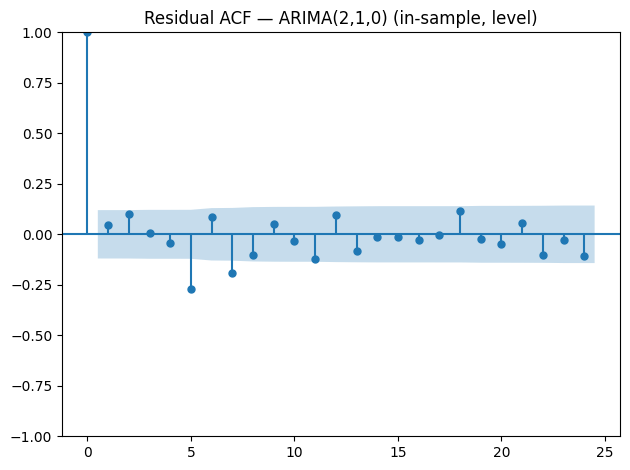

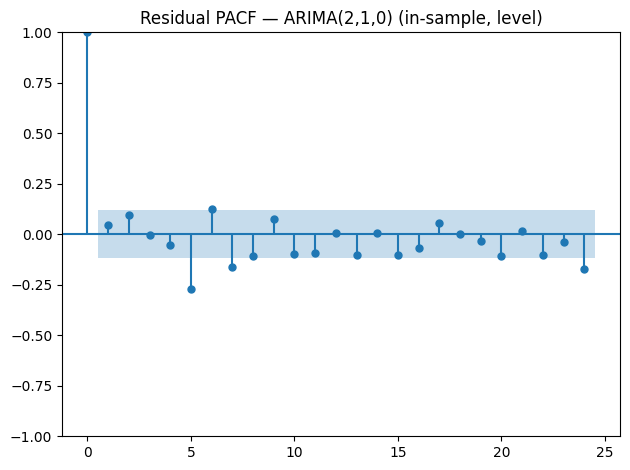


VAR (in-sample, level)
------------------------------
Mean:   -0.000000
Std:    0.427954
Min:    -1.458271
Max:    1.981173

Ljung–Box test (H0: no autocorrelation)
      lb_stat  lb_pvalue
12  10.239945   0.594919
24  29.686961   0.195345
30  47.615969   0.021646
36  52.704110   0.035709
48  65.052206   0.051028


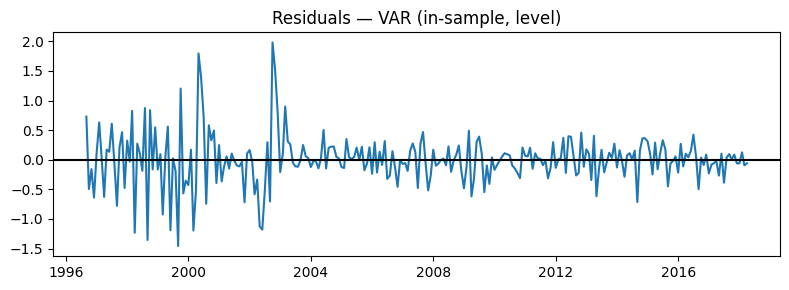

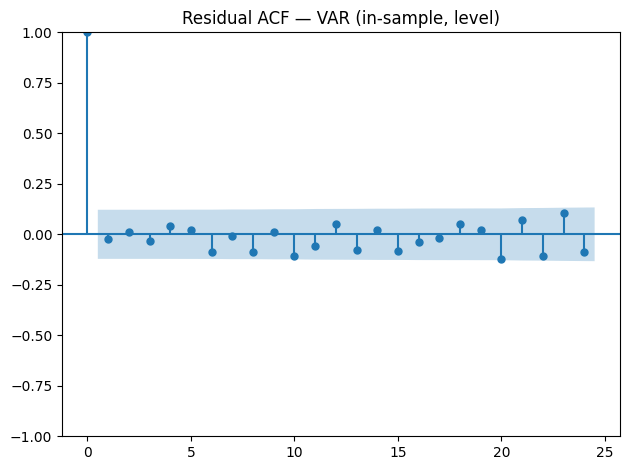

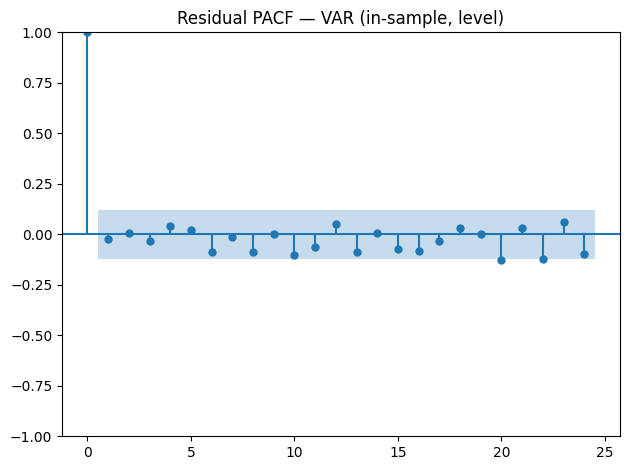


Random Forest (in-sample, level)
------------------------------
Mean:   0.001094
Std:    0.167957
Min:    -0.694253
Max:    0.743860

Ljung–Box test (H0: no autocorrelation)
      lb_stat  lb_pvalue
12  18.372297   0.104845
24  24.214584   0.449383
30  32.719859   0.334828
36  39.183262   0.328977
48  45.406915   0.579713


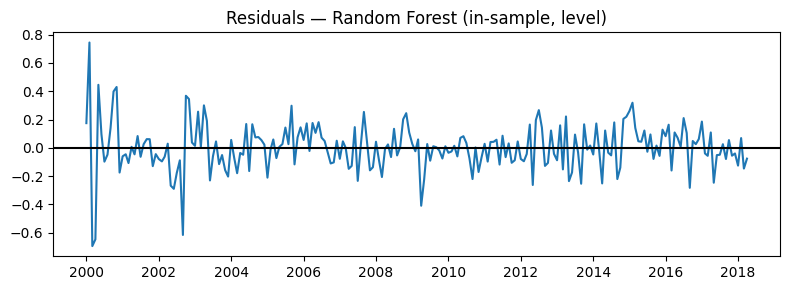

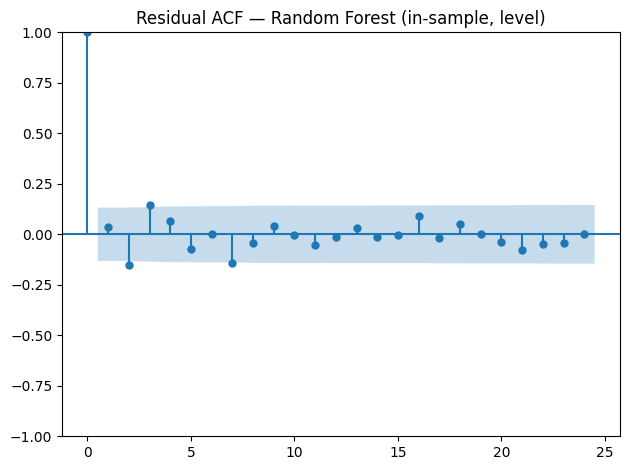

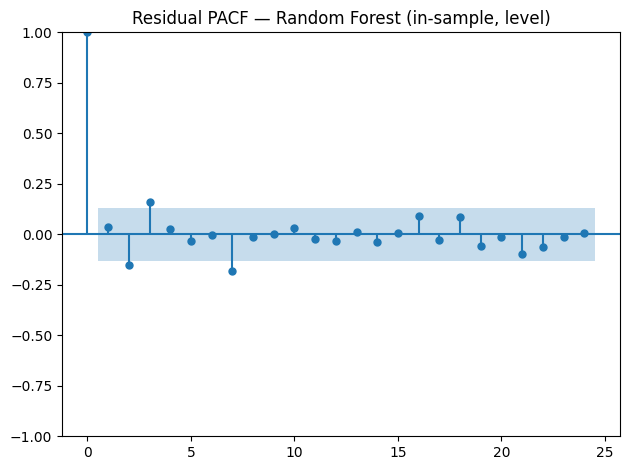

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def quick_resid_diagnostics(resid: pd.Series, title: str):
    print(f"\n{title}")
    print("------------------------------")
    print(f"Mean:   {resid.mean():.6f}")
    print(f"Std:    {resid.std():.6f}")
    print(f"Min:    {resid.min():.6f}")
    print(f"Max:    {resid.max():.6f}")

    # Ljung–Box test
    lb = acorr_ljungbox(resid.dropna(), lags=[12, 24, 30, 36, 48], return_df=True)
    print("\nLjung–Box test (H0: no autocorrelation)")
    print(lb)

    plt.figure(figsize=(8,3))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title(f"Residuals — {title}")
    plt.tight_layout()
    plt.show()

    plot_acf(resid.dropna(), lags=24)
    plt.title(f"Residual ACF — {title}")
    plt.tight_layout()
    plt.show()

    plot_pacf(resid.dropna(), lags=24, method="ywm")
    plt.title(f"Residual PACF — {title}")
    plt.tight_layout()
    plt.show()


# Esempi:
quick_resid_diagnostics(rw_resid_in,          "Random Walk with Drift (in-sample, level)")
quick_resid_diagnostics(arima_210_resid_in,  f"Best ARIMA{best_order} (in-sample, level)")
quick_resid_diagnostics(arima_210_resid_in, "ARIMA(2,1,0) (in-sample, level)")
quick_resid_diagnostics(var_resid_in,         "VAR (in-sample, level)")
quick_resid_diagnostics(rf_resid_in,          "Random Forest (in-sample, level)")

### Confront the forecasts

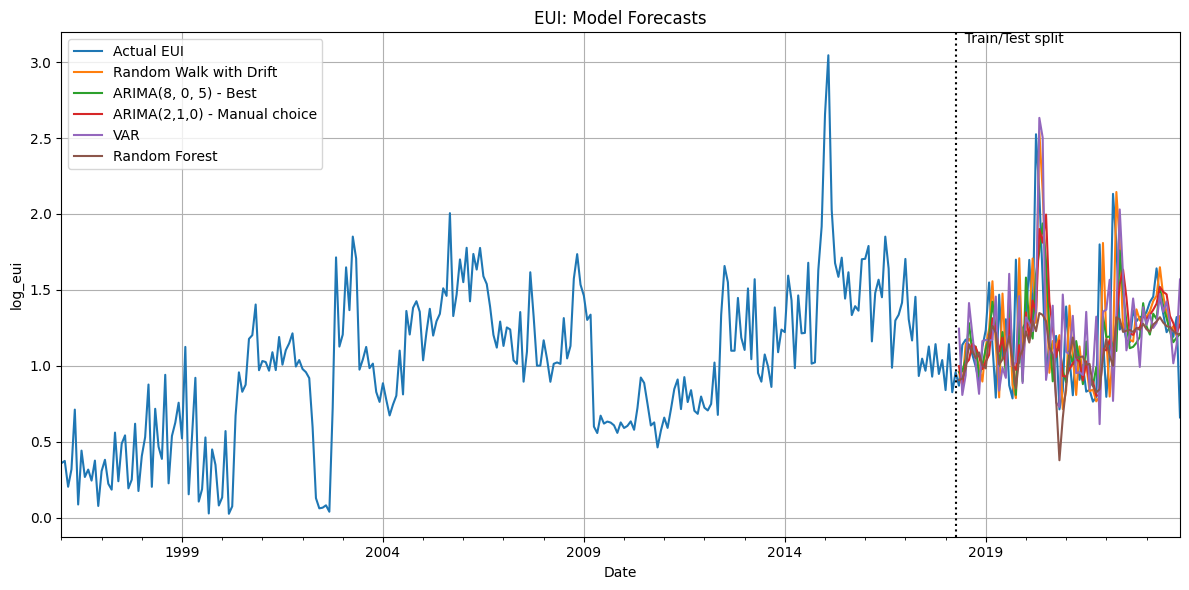

In [36]:
# -----------------------------
# 1. True series (levels)
# -----------------------------
y_train_log = train_df[target_col]
y_test_log  = test_df[target_col]


# -----------------------------
# 2. Build a combined DataFrame including VAR
# -----------------------------
plot_df = pd.DataFrame({
    "train_true": np.exp(y_train_log),
    "test_true": np.exp(y_test_log),
    "rw": np.exp(rw_fcast),                    # RW with drift (expanding)
    "arima_best": np.exp(arima_best_forecast), # best ARIMA from grid
    "arima_210": np.exp(arima_210_forecast),   # fixed ARIMA(2,1,0), expanding
    "rf": np.exp(rf_fcast_series),             # Random Forest
    "var": np.exp(var_log_eui_forecast),           # VAR(dlog_eui, log_gpr, dlog_cpu, dlog_oil_price + dummies)
})

plot_df["actual"] = plot_df["train_true"].fillna(plot_df["test_true"])

# -----------------------------
# 3. Plot: train, test, forecasts
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

plot_df["actual"].plot(
    ax=ax,
    label="Actual EUI",
)

# Model forecasts on test period
plot_df["rw"].plot(
    ax=ax,
    label="Random Walk with Drift",
)
plot_df["arima_best"].plot(
    ax=ax,
    label=f"ARIMA{best_order} - Best",
)
plot_df["arima_210"].plot(
    ax=ax,
    label="ARIMA(2,1,0) - Manual choice",
)
plot_df["var"].plot(
    ax=ax,
    label="VAR",
)
plot_df["rf"].plot(
    ax=ax,
    label="Random Forest",
)

# Vertical line at train/test split
split_date = train_df.index[-1]
ax.axvline(split_date, color="black", linestyle=":", linewidth=1.5)
ax.text(
    split_date,
    ax.get_ylim()[1],
    "  Train/Test split",
    va="top",
    ha="left",
)

ax.set_title("EUI: Model Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


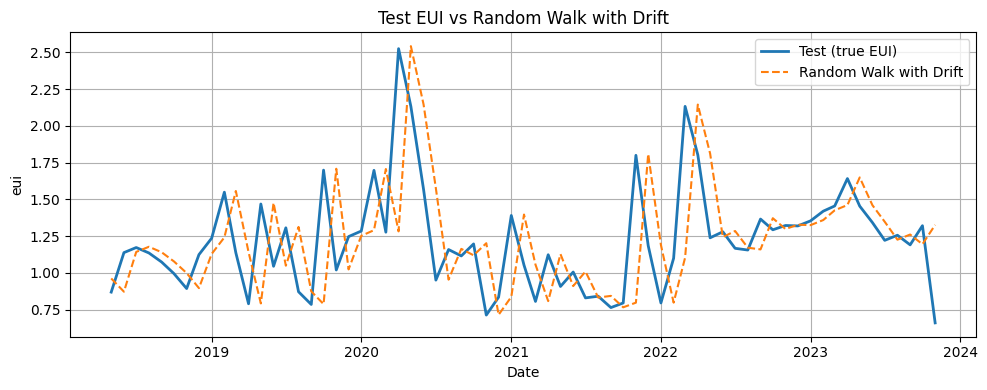

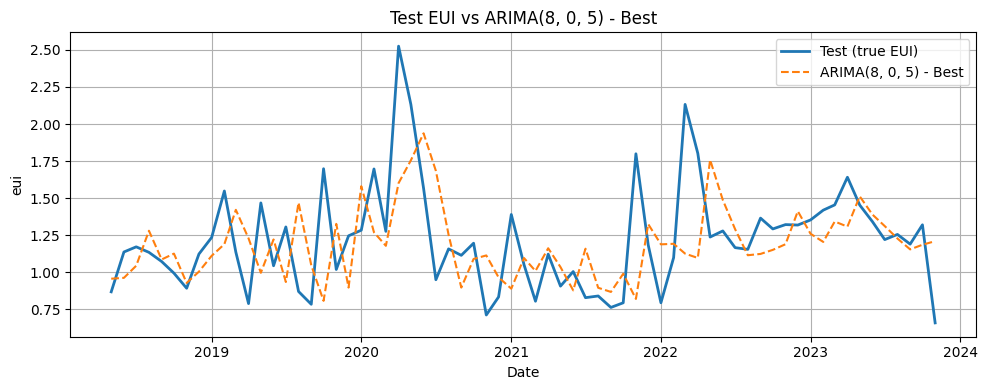

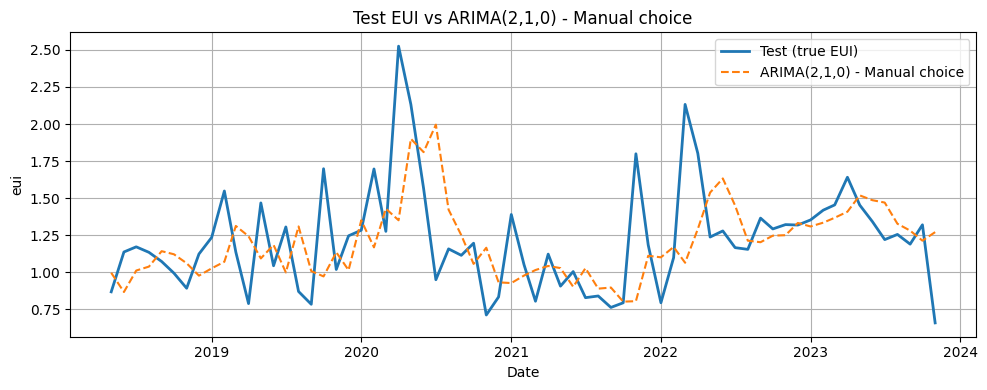

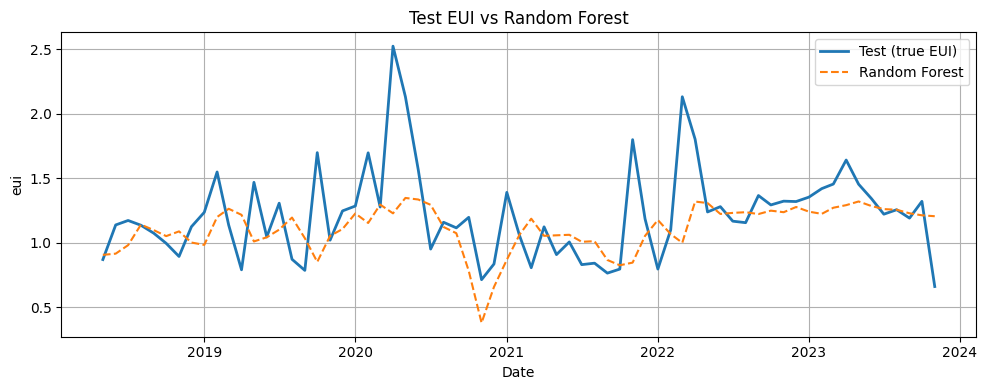

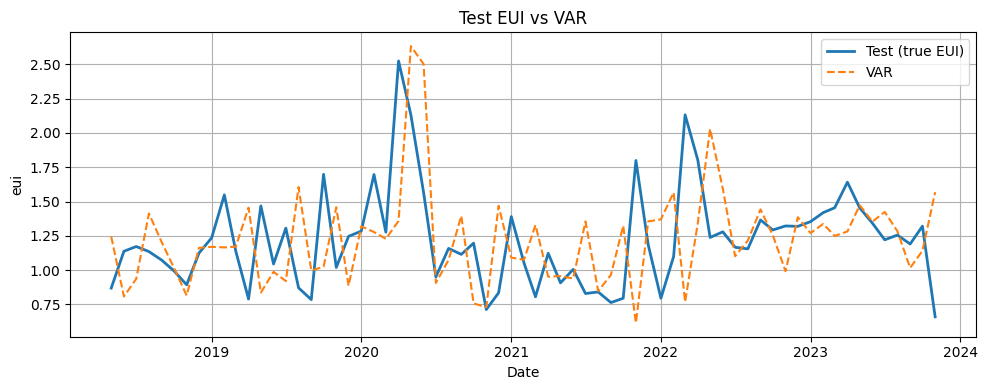

In [37]:
# ---------------------------------------------------
# Plots: true test EUI vs each model forecast (separately)
# ---------------------------------------------------

y_true_test = test_df["eui"]

forecast_dict = {
    "Random Walk with Drift": np.exp(rw_fcast).reindex(y_true_test.index),
    f"ARIMA{best_order} - Best": np.exp(arima_best_forecast).reindex(y_true_test.index),
    "ARIMA(2,1,0) - Manual choice": np.exp(arima_210_forecast).reindex(y_true_test.index),
    "Random Forest": np.exp(rf_fcast_series).reindex(y_true_test.index),
    "VAR": np.exp(var_log_eui_forecast).reindex(y_true_test.index),
}

for model_name, y_hat in forecast_dict.items():
    # Drop any rows where either true or forecast is missing
    tmp = pd.concat([y_true_test, y_hat], axis=1, keys=["y_true", "y_hat"]).dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    # True values (test)
    ax.plot(
        tmp.index,
        tmp["y_true"],
        label="Test (true EUI)",
        linewidth=2,
    )

    # Model forecast
    ax.plot(
        tmp.index,
        tmp["y_hat"],
        label=f"{model_name}",
        linestyle="--",
    )

    ax.set_title(f"Test EUI vs {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("eui")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


### Evaluate the forecasts

In [38]:
# Metrics with EUI Levels
def compute_metrics(y_true, y_pred):
    """
    Returns a dictionary with MSFE, RMSFE, MAFE, MAPE.
    """
    err = y_true - y_pred
    abs_err = np.abs(err)

    metrics = {
        "MSFE": np.mean(err ** 2),
        "RMSFE": np.sqrt(np.mean(err ** 2)),
        "MAFE": np.mean(abs_err),
        "MAPE": np.mean(abs_err / np.abs(y_true)) * 100,
    }
    return metrics
# Align predictions with the true test values (levels)
y_true = test_df["eui"]

metrics_rw        = compute_metrics(y_true, np.exp(rw_fcast))
metrics_arimaBest = compute_metrics(y_true, np.exp(arima_best_forecast))
metrics_arima210  = compute_metrics(y_true, np.exp(arima_210_forecast))
metrics_rf        = compute_metrics(y_true, np.exp(rf_fcast_series))
metrics_var       = compute_metrics(y_true, np.exp(var_log_eui_forecast))

metrics_df = pd.DataFrame({
    "Random Walk with Drift": metrics_rw,
    f"ARIMA{best_order} - Best": metrics_arimaBest,
    "ARIMA(2,1,0) - Manual choice": metrics_arima210,
    "Random Forest": metrics_rf,
    "VAR": metrics_var,
}).T

print("\n=== Forecast Accuracy Comparison ===")
print(metrics_df.round(4))


=== Forecast Accuracy Comparison ===
                                MSFE   RMSFE    MAFE     MAPE
Random Walk with Drift        0.1551  0.3938  0.2828  23.2511
ARIMA(8, 0, 5) - Best         0.1290  0.3592  0.2671  22.0186
ARIMA(2,1,0) - Manual choice  0.1305  0.3613  0.2554  21.0793
Random Forest                 0.1266  0.3559  0.2343  18.4789
VAR                           0.1983  0.4453  0.3187  26.9425
